SCENARIO 3 – RANDOM FOREST (Income)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

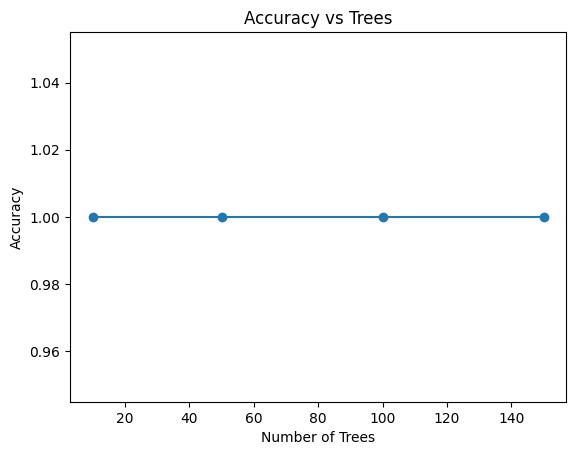

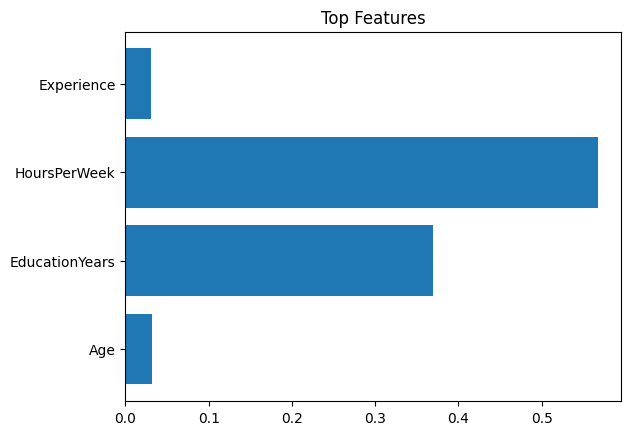

In [ ]:
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv("income_random_forest.csv")

# df = pd.get_dummies(df, drop_first=True) # This is not needed as data is already numeric

X = df.drop("Income", axis=1)
y = df["Income"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

trees = [10, 50, 100, 150]
acc_list = []

for n in trees:
    rf = RandomForestClassifier(n_estimators=n)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)
    acc_list.append(accuracy_score(y_test, y_pred))

# Graph
plt.plot(trees, acc_list, marker='o')
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Trees")
plt.show()

# Feature Importance
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

plt.barh(X.columns[:10], rf.feature_importances_[:10])
plt.title("Top Features")
plt.show()